In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [29]:
# Read the CSV file into a DataFrame
train_df = pd.read_csv('./data/train.csv')
meal_info_df = pd.read_csv('./data/meal_info.csv')
fc_info_df = pd.read_csv('./data/fulfilment_center_info.csv')

In [30]:
print(f'MEAL SHAPE={meal_info_df.shape}')
print(f'FC SHAPE={fc_info_df.shape}')

MEAL SHAPE=(51, 3)
FC SHAPE=(77, 5)


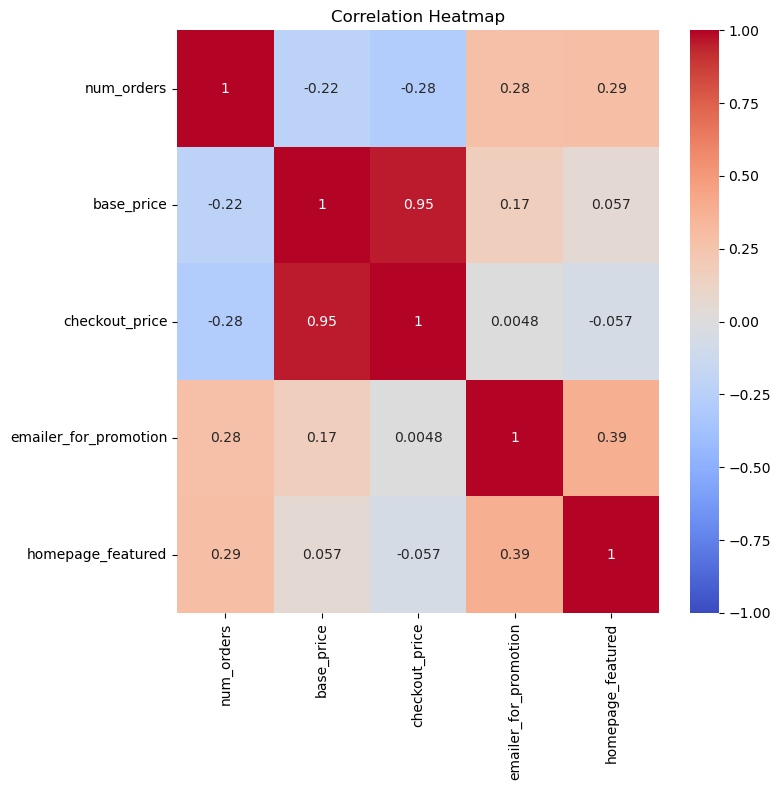

In [31]:
selected_df = train_df[['num_orders', 'base_price', 'checkout_price', 'emailer_for_promotion', 'homepage_featured']]

plt.figure(figsize=(8, 8))
sns.heatmap(selected_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

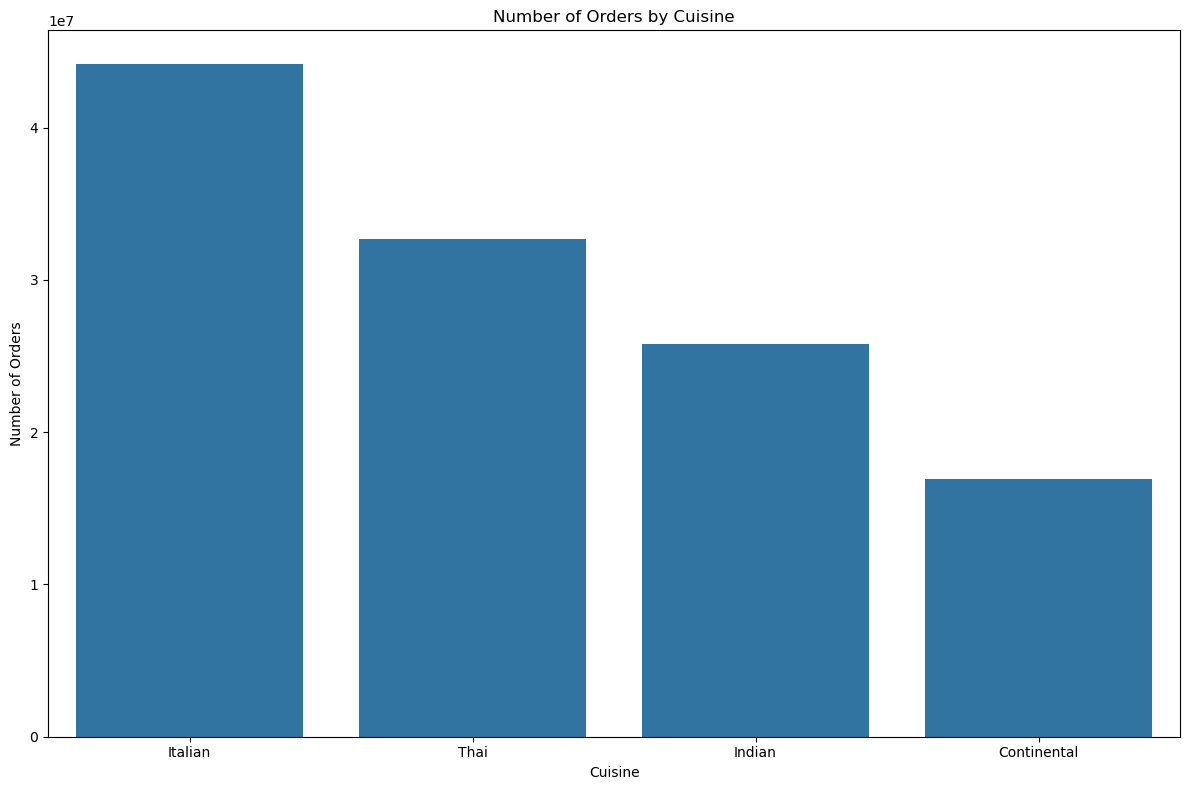

In [32]:
# Join meal_info_df with train dataframe
train_with_meal = train_df.merge(meal_info_df, on='meal_id', how='left')

# Group num_orders by cuisine
cuisine_orders = train_with_meal.groupby('cuisine').agg({'num_orders': 'sum'}).reset_index().sort_values('num_orders', ascending=False)

# Create bar chart
plt.figure(figsize=(12, 8))
sns.barplot(data=cuisine_orders, x='cuisine', y='num_orders')
plt.title('Number of Orders by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


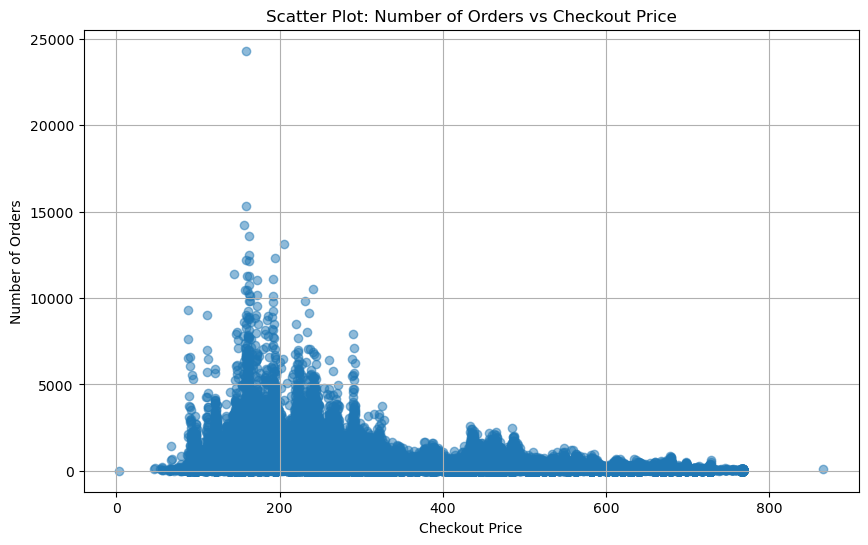

In [33]:
plt.figure(figsize=(10, 6))
plt.scatter(train_df['checkout_price'], train_df['num_orders'], alpha=0.5)
plt.xlabel('Checkout Price')
plt.ylabel('Number of Orders')
plt.title('Scatter Plot: Number of Orders vs Checkout Price')
plt.grid(True)

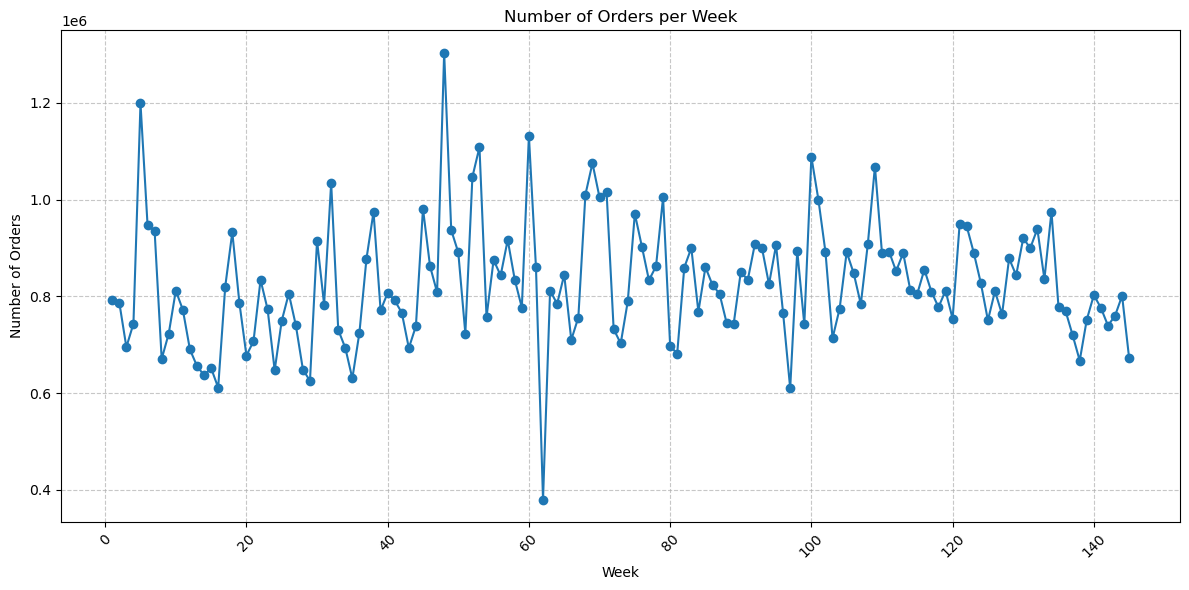

In [34]:
# Group data by week and sum the number of orders
weekly_orders = train_df.groupby('week')['num_orders'].sum().reset_index()

# Create the line plot
plt.figure(figsize=(12, 6))
plt.plot(weekly_orders['week'], weekly_orders['num_orders'], marker='o')

# Customize the plot
plt.title('Number of Orders per Week')
plt.xlabel('Week')
plt.ylabel('Number of Orders')
plt.grid(True, linestyle='--', alpha=0.7)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


In [35]:
# Group by center_id and count the number of orders
grouped_orders_fcs = train_df.groupby(['week', 'center_id']).agg({'num_orders': 'sum'}).reset_index().sort_values(['week', 'center_id'])

# Iterate over each center_id
for (center_id,), group in grouped_orders_fcs.groupby(['center_id']):
    plt.figure(figsize=(12, 6))
    plt.plot(group['week'], group['num_orders'])
    plt.title(f'Number of Orders by Week for Center {center_id}')
    plt.xlabel('Week')
    plt.ylabel('Number of Orders')
    plt.grid(True)
    
    if not os.path.exists(f'plots/fcs/'):
        os.makedirs(f'plots/fcs/')

    # Save the plot
    plt.savefig(f'plots/fcs/fc_{center_id}_orders.png')
    plt.close()  # Close the figure to free up memory

print(f"Plots have been saved in the 'plots/fcs' directory.")


Plots have been saved in the 'plots/fcs' directory.


In [36]:
# Group by meal_id and count the number of orders
grouped_orders_meals = train_df.groupby(['week', 'meal_id']).agg({'num_orders': 'sum'}).reset_index().sort_values(['week', 'meal_id'])

# Iterate over meal_id
for (meal_id,), group in grouped_orders_meals.groupby(['meal_id']):
    plt.figure(figsize=(12, 6))
    plt.plot(group['week'], group['num_orders'])
    plt.title(f'Number of Orders by Week for Meal {meal_id}')
    plt.xlabel('Week')
    plt.ylabel('Number of Orders')
    plt.grid(True)
    
    if not os.path.exists(f'plots/meals/'):
        os.makedirs(f'plots/meals/')

    # Save the plot
    plt.savefig(f'plots/meals/meal_{meal_id}_orders.png')
    plt.close()  # Close the figure to free up memory

print(f"Plots have been saved in the 'plots/meals' directory.")


Plots have been saved in the 'plots/meals' directory.


In [37]:
# Group by meal_id and center_id, and count the number of orders
grouped_orders = train_df.groupby(['week', 'center_id', 'meal_id']).agg({'num_orders': 'sum'}).reset_index().sort_values(['week', 'center_id', 'meal_id'])

# Iterate over each unique combination of center_id and meal_id
for (center_id, meal_id), group in grouped_orders.groupby(['center_id', 'meal_id']):
    plt.figure(figsize=(12, 6))
    plt.plot(group['week'], group['num_orders'])
    plt.title(f'Number of Orders by Week for Center {center_id}, Meal {meal_id}')
    plt.xlabel('Week')
    plt.ylabel('Number of Orders')
    plt.grid(True)
    
    if not os.path.exists(f'plots/fcs_meals/center_{center_id}'):
        os.makedirs(f'plots/fcs_meals/center_{center_id}')

    # Save the plot
    plt.savefig(f'plots/fcs_meals/center_{center_id}/meal_{meal_id}_orders.png')
    plt.close()  # Close the figure to free up memory

print(f"Plots have been saved in the 'plots' directory.")


Plots have been saved in the 'plots' directory.
